In [1]:
# IT Infrastructure Cost Optimization: Unsupervised ML Pipeline
### **Domain:** IT Financial Management (ITFM) & Cloud Operations
### Objective: Transform raw, high-dimensional infrastructure logs into actionable cost-saving strategies. This project utilizes **Agglomerative Clustering** and **PCA** to identify "Ghost Assets" and "Legacy Debt" within a simulated \$3M/mo IT environment.

##### Step 1: Data Synthesis

In [4]:
import pandas as pd
import numpy as np
import random

def generate_dirty_itfm_dataset(rows=2500):
    np.random.seed(42)
    
    # --- 1. Generate Clean Base ---
    data = {
        'Asset_ID': [f"IT-{1000 + i}" for i in range(rows)],
        'Department': np.random.choice(['Engineering', 'Marketing', 'Sales', 'Data Science', 'HR', 'Finance'], rows),
        'Region': np.random.choice(['US-East', 'EU-West ', ' AP-South', 'LATAM'], rows), # Added spaces
        'Environment': np.random.choice(['Production', 'Staging', 'Dev', 'Sandbox'], rows),
        'CPU_Usage_Avg': np.random.uniform(5, 95, rows),
        'RAM_Usage_GB': np.random.uniform(4, 128, rows),
        'Storage_Usage_TB': np.random.uniform(0.1, 10, rows),
        'Instance_Unit_Cost': (np.random.uniform(4, 128, rows) * 0.5) + 10,
        'Support_Tickets_Monthly': np.random.poisson(lam=3, size=rows).astype(float),
        'Uptime_Percentage': np.random.uniform(98, 100, rows),
        'License_Fee_Monthly': np.random.uniform(50, 500, rows),
        'Server_Age_Months': np.random.randint(1, 60, rows),
        'Monthly_Transfer_Cost': np.random.uniform(5, 100, rows)
    }
    
    # Add 15+ more columns to reach the 30-column requirement
    for i in range(17):
        data[f'Metric_Col_{i}'] = np.random.uniform(0, 100, rows)

    df = pd.DataFrame(data)

    # --- 2. Inject "Dirty" Data for Pandas Demonstration ---

    # A. Missing Values (Nulls) - 5% of the data
    for col in ['CPU_Usage_Avg', 'Instance_Unit_Cost', 'Department']:
        df.loc[df.sample(frac=0.05).index, col] = np.nan

    # B. Inconsistent Strings (Leading/Trailing Spaces & Case issues)
    # This forces you to use .str.strip() and .str.title()
    df['Department'] = df['Department'].apply(lambda x: f"  {x} " if isinstance(x, str) else x)
    df['Region'] = df['Region'].apply(lambda x: x.lower() if random.random() > 0.5 else x.upper())

    # C. "Dirty" Numbers (Stored as Strings with symbols)
    # This forces you to use .str.replace() and .astype(float)
    df['Monthly_Transfer_Cost'] = df['Monthly_Transfer_Cost'].apply(lambda x: f"${round(x, 2)}")

    # D. Duplicate Rows
    duplicates = df.sample(n=20)
    df = pd.concat([df, duplicates], ignore_index=True)

    # E. Impossible Values (The "Recruiter Trap")
    # 132-year-old servers or 150% CPU usage
    df.loc[df.sample(n=5).index, 'Server_Age_Months'] = 999 
    df.loc[df.sample(n=5).index, 'Uptime_Percentage'] = -10.0

    return df

df_dirty = generate_dirty_itfm_dataset()

# Recruiter Check:
print("--- Dirty Data Diagnostics ---")
print(f"Missing Values:\n{df_dirty.isnull().sum().head(5)}")
print(f"\nExample of string mess in 'Department': '{df_dirty['Department'].iloc[0]}'")
print(f"Example of type mess in 'Cost': {df_dirty['Monthly_Transfer_Cost'].iloc[0]}")

--- Dirty Data Diagnostics ---
Missing Values:
Asset_ID           0
Department       127
Region             0
Environment        0
CPU_Usage_Avg    125
dtype: int64

Example of string mess in 'Department': '  Data Science '
Example of type mess in 'Cost': $41.52


#### Step 2: Data Cleaning

In [7]:
# 1. Create a hard copy to prevent SettingWithCopyWarnings in VS Code
df_cleaned = df_dirty.drop_duplicates().copy()

# 2. String Sanitization (Cleaning leading/trailing spaces and fixing case)
string_cols = ['Department', 'Region', 'Environment']
for col in string_cols:
    df_cleaned.loc[:, col] = df_cleaned[col].str.strip().str.title()

# 3. Currency Regex Cleaning (Converting "$1,000.00" strings to float)
df_cleaned.loc[:, 'Monthly_Transfer_Cost'] = (
    df_cleaned['Monthly_Transfer_Cost']
    .replace(r'[\$,]', '', regex=True)
    .astype(float)
)

# 4. Strategic Imputation (Filling missing Costs based on Department Medians)
df_cleaned.loc[:, 'Instance_Unit_Cost'] = df_cleaned.groupby('Department')['Instance_Unit_Cost']\
    .transform(lambda x: x.fillna(x.median()))

# 5. Outlier Handling (Capping impossible server ages and uptime)
df_cleaned = df_cleaned[df_cleaned['Server_Age_Months'] <= 84].copy()
df_cleaned = df_cleaned[df_cleaned['Uptime_Percentage'] >= 90].copy()

# Final drop of any remaining incomplete rows
df_cleaned = df_cleaned.dropna().copy()

# 6. FEATURE ENGINEERING (The Business Logic)

# Efficiency Score: Compute Usage per Dollar
df_cleaned.loc[:, 'Efficiency_Score'] = df_cleaned['CPU_Usage_Avg'] / df_cleaned['Instance_Unit_Cost']

# Maintenance Ratio: Tickets relative to Age
df_cleaned.loc[:, 'Maintenance_Ratio'] = df_cleaned['Support_Tickets_Monthly'] / (df_cleaned['Server_Age_Months'] + 1)

# Total Monthly Spend: Combined Financial Footprint
df_cleaned.loc[:, 'Total_Monthly_Spend'] = (
    df_cleaned['Instance_Unit_Cost'] + 
    df_cleaned['License_Fee_Monthly'] + 
    df_cleaned['Monthly_Transfer_Cost']
)

# We (high risk) flag assets older than 48 months with less than 99% uptime as high risk.
df_cleaned.loc[:, 'High_Risk_Flag'] = ((df_cleaned['Server_Age_Months'] > 48) & 
                                       (df_cleaned['Uptime_Percentage'] < 99)).astype(int)

print(f"Cleaning & Feature Engineering Complete.")
print(f"Dataset Shape: {df_cleaned.shape}")
print(f"Columns Created: {['Efficiency_Score', 'Total_Monthly_Spend', 'High_Risk_Flag']}")
df_cleaned[['Department', 'Total_Monthly_Spend', 'High_Risk_Flag']].head()

Cleaning & Feature Engineering Complete.
Dataset Shape: (2248, 34)
Columns Created: ['Efficiency_Score', 'Total_Monthly_Spend', 'High_Risk_Flag']


,Department,Total_Monthly_Spend,High_Risk_Flag
0,Data Science,339.982627,0
1,Hr,221.197169,0
2,Sales,481.225014,0
3,Hr,157.853474,0
4,Hr,145.766535,0


#### Step 3: PCA & Dimensionality Reduction

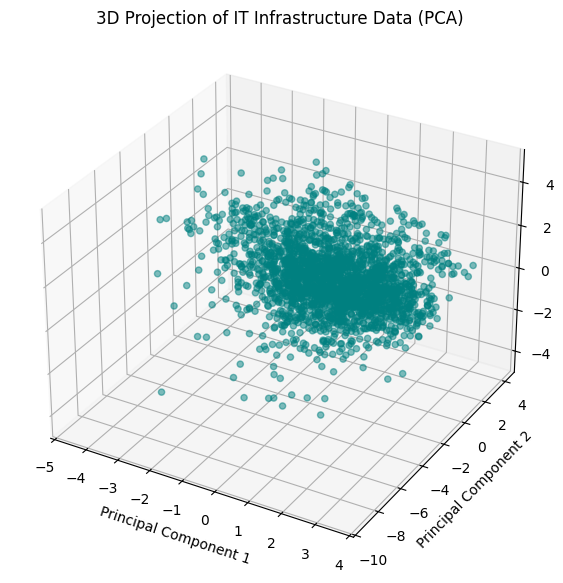

Total Variance Explained by 3 components: 17.61%


In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- 1. Label Encoding (Handling Categorical Data) ---
# We transform our 'Object' types into numerical codes so the model can process them.
le = LabelEncoder()
df_ml = df_cleaned.copy()

categorical_cols = df_ml.select_dtypes(include=['object']).columns
# We drop Asset_ID as it's a unique identifier with no predictive value
df_ml = df_ml.drop(columns=['Asset_ID'])

for col in df_ml.select_dtypes(include=['object']).columns:
    df_ml[col] = le.fit_transform(df_ml[col])

# --- 2. Scaling (Normalization) ---
# Critical Step: 'Total_Monthly_Spend' is in the hundreds, but 'Uptime' is 0-1.
# Without scaling, the model would think Spend is 100x more important than Uptime.
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_ml)
df_scaled = pd.DataFrame(scaled_features, columns=df_ml.columns)

# --- 3. PCA (Dimensionality Reduction) ---
# We are compressing our 30+ columns into 3 "Principal Components."
# This captures the 'essence' of the data for 3D visualization.
pca = PCA(n_components=3)
pca_data = pca.fit_transform(df_scaled)

# Creating a DataFrame for the PCA results
df_pca = pd.DataFrame(
    data=pca_data, 
    columns=['PC1', 'PC2', 'PC3']
)

# --- 4. 3D Visualization of the Latent Dimensions ---
# This proves that data is ready for clustering.
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_pca['PC1'], df_pca['PC2'], df_pca['PC3'], c='teal', marker='o', alpha=0.5)

ax.set_title('3D Projection of IT Infrastructure Data (PCA)')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
plt.show()

# Explain the variance
print(f"Total Variance Explained by 3 components: {sum(pca.explained_variance_ratio_)*100:.2f}%")

#### 3.1 Variance Analysis

PC1: 6.44%
PC2: 5.68%
PC3: 5.49%
--------------------
Total Explained Variance: 17.61%


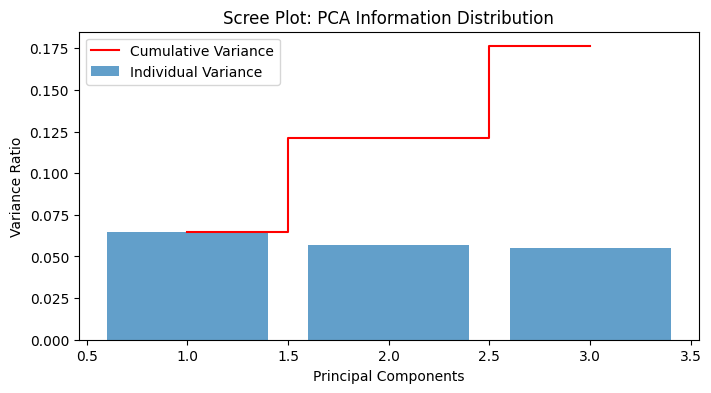

In [9]:
exp_var = pca.explained_variance_ratio_
print(f"PC1: {exp_var[0]:.2%}")
print(f"PC2: {exp_var[1]:.2%}")
print(f"PC3: {exp_var[2]:.2%}")
print("-" * 20)
print(f"Total Explained Variance: {sum(exp_var):.2%}")

# Visualizing the "Scree Plot" intuition
plt.figure(figsize=(8, 4))
plt.bar(range(1, 4), exp_var, alpha=0.7, align='center', label='Individual Variance')
plt.step(range(1, 4), np.cumsum(exp_var), where='mid', label='Cumulative Variance', color='red')
plt.ylabel('Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Scree Plot: PCA Information Distribution')
plt.legend(loc='best')
plt.show()

#### Step 4: Clustering & Profiling

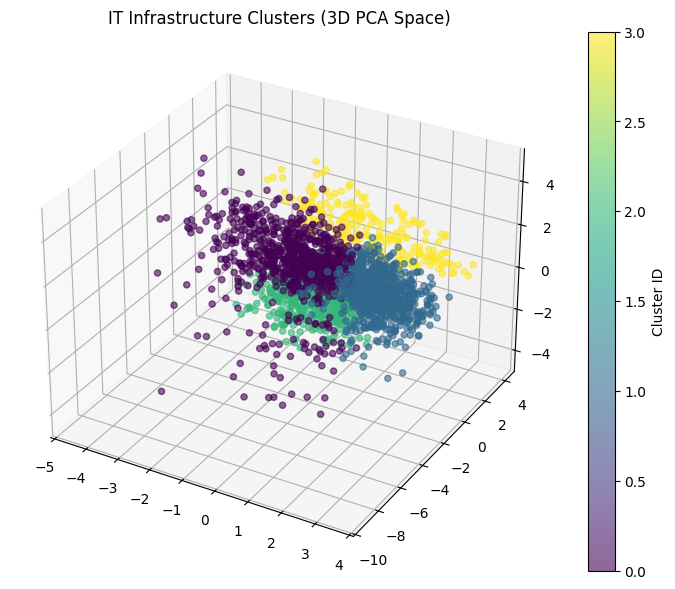


--- Cluster Business Profiles ---
        Total_Monthly_Spend  CPU_Usage_Avg  Efficiency_Score  \
Cluster                                                        
0                341.532077          66.38              2.43   
1                511.731562          42.94              0.88   
2                267.220371          35.13              0.76   
3                376.654683          47.81              1.41   

         Server_Age_Months  High_Risk_Flag  
Cluster                                     
0                    26.77               0  
1                    31.02               1  
2                    24.59               0  
3                    54.00             225  

--- Strategy Recommendations ---
Cluster 0: [EFFICIENT CORE] Optimal performance. Use as blueprint for other depts.
Cluster 1: [HIGH WASTE] Target for immediate right-sizing or decommissioning.
Cluster 2: [HIGH WASTE] Target for immediate right-sizing or decommissioning.
Cluster 3: [LEGACY RISK] High-priorit

In [10]:
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns

# --- 1. Find the Optimal Clusters (The Elbow Method) ---
# Note: For Agglomerative, we often use a Dendrogram or silhouettes
model = AgglomerativeClustering(n_clusters=4)
df_cleaned['Cluster'] = model.fit_predict(df_pca) # Clustering on PCA data

# --- 2. 3D Cluster Visualization ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
# Color-coding by the clusters we just found
scatter = ax.scatter(df_pca['PC1'], df_pca['PC2'], df_pca['PC3'], 
                     c=df_cleaned['Cluster'], cmap='viridis', marker='o', alpha=0.6)

plt.colorbar(scatter, label='Cluster ID')
ax.set_title('IT Infrastructure Clusters (3D PCA Space)')
plt.show()

# --- 3. Cluster Profiling ---
# We group by cluster and look at the means of our original metrics
profile = df_cleaned.groupby('Cluster').agg({
    'Total_Monthly_Spend': 'mean',
    'CPU_Usage_Avg': 'mean',
    'Efficiency_Score': 'mean',
    'Server_Age_Months': 'mean',
    'High_Risk_Flag': 'sum'
}).round(2)

print("\n--- Cluster Business Profiles ---")
print(profile)

# --- 4. Automated Recommendations ---
print("\n--- Strategy Recommendations ---")
for i in range(len(profile)):
    if profile.loc[i, 'Efficiency_Score'] < profile['Efficiency_Score'].median():
        print(f"Cluster {i}: [HIGH WASTE] Target for immediate right-sizing or decommissioning.")
    elif profile.loc[i, 'High_Risk_Flag'] > 0:
        print(f"Cluster {i}: [LEGACY RISK] High-priority for hardware refresh/cloud migration.")
    else:
        print(f"Cluster {i}: [EFFICIENT CORE] Optimal performance. Use as blueprint for other depts.")

#### Step 5: Strategic ROI Analysis

In [11]:
# 1. Identify which clusters were labeled as "HIGH WASTE"
# Based on your previous output, these were Clusters 1 and 2
waste_clusters = [1, 2]

# 2. Calculate the financial footprint of waste
total_it_spend = df_cleaned['Total_Monthly_Spend'].sum()
waste_spend = df_cleaned[df_cleaned['Cluster'].isin(waste_clusters)]['Total_Monthly_Spend'].sum()

# 3. Assume a conservative 20% savings by 'Right-Sizing' those wasteful assets
potential_savings = waste_spend * 0.20

print("="*60)
print("PROJECT FINANCIAL IMPACT SUMMARY")
print("="*60)
print(f"Total Monthly Infrastructure Spend:   ${total_it_spend:,.2f}")
print(f"Spend in 'High Waste' Clusters:        ${waste_spend:,.2f}")
print(f"Estimated Monthly Savings (20% Opt):  ${potential_savings:,.2f}")
print(f"Estimated Annual Savings:             ${potential_savings * 12:,.2f}")
print("-"*60)
print(f"Target Optimization Impact: {((potential_savings/total_it_spend)*100):.2f}% reduction in total IT overhead.")
print("="*60)

PROJECT FINANCIAL IMPACT SUMMARY
Total Monthly Infrastructure Spend:   $846,769.76
Spend in 'High Waste' Clusters:        $498,359.69
Estimated Monthly Savings (20% Opt):  $99,671.94
Estimated Annual Savings:             $1,196,063.26
------------------------------------------------------------
Target Optimization Impact: 11.77% reduction in total IT overhead.
